# **K Nearest Neighbors**

K Nearest Neighbors (KNN) adalah algoritma pembelajaran mesin yang digunakan untuk klasifikasi dan regresi. KNN bekerja dengan mencari K tetangga terdekat dari data yang ingin diprediksi, kemudian menggunakan informasi dari tetangga tersebut untuk membuat prediksi.


## **Import Libraries**


In [ ]:
# Uncommeend jika belum mendownload librari yang dibutuhkan
# %pip install opencv-python
# %pip install numpy 
# %pip install matplotlib 
# %pip install seaborn 
# %pip install scikit-image 
# %pip install scikit-learn
# %pip install joblib

In [75]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from skimage.feature import hog, graycomatrix, graycoprops
from skimage import exposure
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

## **Data Understanding**


In [4]:
DATASET_PATH = './data'
KATEGORI = ['Plastic', 'Paper', 'Metal', 'Glass', 'Biological']

In [5]:
all_files = []
for root, dirs, files in os.walk(DATASET_PATH):
	for fname in files:
		if fname.lower().endswith(('.jpg')):
			all_files.append(os.path.join(root, fname))

print(f"Total file: {len(all_files)}")

Total file: 8720


In [6]:
jumlah_data = []
for kategori in KATEGORI:
  folder_path = os.path.join(DATASET_PATH, kategori)
  if os.path.exists(folder_path):
    jumlah = len(os.listdir(folder_path))
    jumlah_data.append(jumlah)
    print(f"Dataset {kategori}: {jumlah} gambar")
  else:
    jumlah_data.append(0)
    print(f"Peringatan: Folder {kategori} tidak ditemukan!")

Dataset Plastic: 1984 gambar
Dataset Paper: 1680 gambar
Dataset Metal: 1019 gambar
Dataset Glass: 3061 gambar
Dataset Biological: 997 gambar


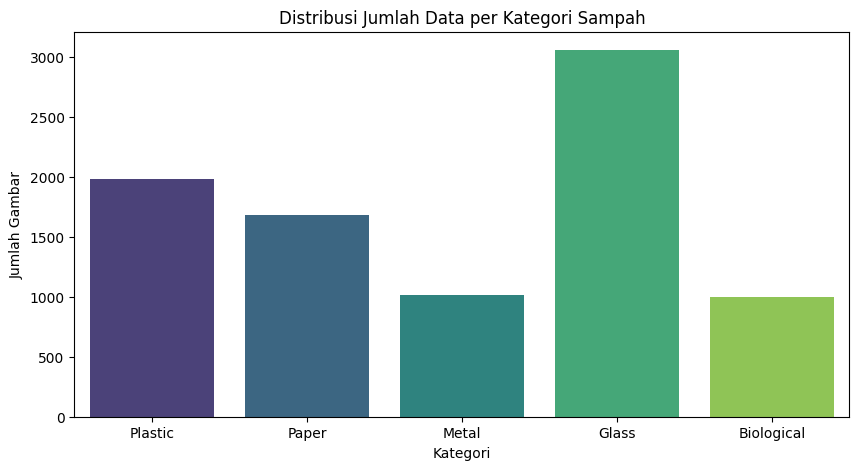

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(x=KATEGORI, y=jumlah_data, palette="viridis", hue=KATEGORI, legend=False)
plt.title("Distribusi Jumlah Data per Kategori Sampah")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Gambar")
plt.show();

## **Data Preparation**


In [76]:
def extract_features(image, return_visual=False):
  # Histogram RGB
  hist_r = cv2.calcHist([image], [0], None, [32], [0, 256]).flatten()
  hist_g = cv2.calcHist([image], [1], None, [32], [0, 256]).flatten()
  hist_b = cv2.calcHist([image], [2], None, [32], [0, 256]).flatten()
  
  # Histogram HSV
  hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
  hist_h = cv2.calcHist([hsv_image], [0], None, [32], [0, 256]).flatten()
  hist_s = cv2.calcHist([hsv_image], [1], None, [32], [0, 256]).flatten()
  hist_v = cv2.calcHist([hsv_image], [2], None, [32], [0, 256]).flatten()
  
  # GLCM (Analisis Tekstur Spasial)
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  glcm = graycomatrix(
    gray_image, 
    distances=[1], 
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], 
    levels=256, symmetric=True, normed=True
  )
  contrast = graycoprops(glcm, 'contrast').flatten()
  correlation = graycoprops(glcm, 'correlation').flatten()
  energy = graycoprops(glcm, 'energy').flatten()
  homogeneity = graycoprops(glcm, 'homogeneity').flatten()
  
  # HOG (Bentuk)
  if return_visual:
    hog_features, hog_image = hog(
			gray_image, orientations=8,
			pixels_per_cell=(16, 16), cells_per_block=(1, 1),
			visualize=True
		)
    return (
			np.concatenate([hist_r, hist_g, hist_b,
											hist_h, hist_s, hist_v,
											contrast, correlation, energy, homogeneity,
											hog_features]),
			hist_r, hist_g, hist_b, hog_image
		)
  else:
    hog_features = hog(
      gray_image, orientations=8, 
      pixels_per_cell=(16, 16), cells_per_block=(1, 1), 
      visualize=False
    )
    return np.concatenate([hist_r, hist_g, hist_b, 
                          hist_h, hist_s, hist_v, 
                          contrast, correlation, energy, homogeneity, 
                          hog_features])

In [77]:
contoh_path = os.path.join(DATASET_PATH, KATEGORI[0], os.listdir(os.path.join(DATASET_PATH, KATEGORI[0]))[0])
contoh_img = cv2.imread(contoh_path)
contoh_img_resized = cv2.resize(contoh_img, (128, 128))

fitur_lengkap, hr, hg, hb, hog_vis = extract_features(contoh_img_resized, return_visual=True)
print(f"Total ukuran vektor fitur per gambar: {len(fitur_lengkap)} dimensi")

Total ukuran vektor fitur per gambar: 720 dimensi


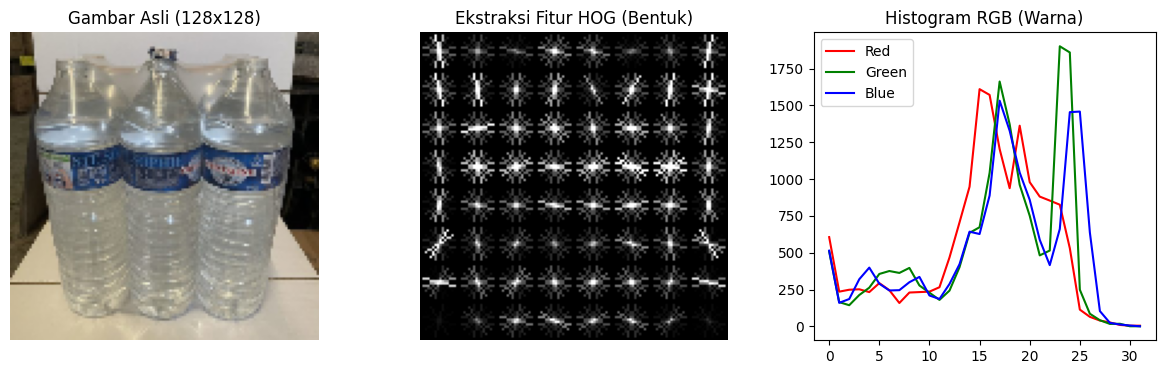

In [78]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.imshow(cv2.cvtColor(contoh_img_resized, cv2.COLOR_BGR2RGB))
ax1.set_title('Gambar Asli (128x128)')
ax1.axis('off')

hog_image_rescaled = exposure.rescale_intensity(hog_vis, in_range=(0, 10))
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Ekstraksi Fitur HOG (Bentuk)')
ax2.axis('off')

ax3.plot(hr, color='r', label='Red')
ax3.plot(hg, color='g', label='Green')
ax3.plot(hb, color='b', label='Blue')
ax3.set_title('Histogram RGB (Warna)')
ax3.legend()
plt.show()

## **Feature Extraction**


In [100]:
X, y = [], []

for label_idx, kategori in enumerate(KATEGORI):
  folder_path = os.path.join(DATASET_PATH, kategori)
  if not os.path.exists(folder_path): continue
  
  for filename in os.listdir(folder_path):
    img_path = os.path.join(folder_path, filename)
    img = cv2.imread(img_path)
    if img is not None:
      img_resized = cv2.resize(img, (128, 128))
      fetures = extract_features(img_resized)
      X.append(fetures)
      y.append(label_idx)

In [101]:
X = np.array(X)
y = np.array(y)

print(f"Dataset siap -> X: {X.shape}, y: {y.shape}")

Dataset siap -> X: (8741, 720), y: (8741,)


In [102]:
# Data Splitting 80:20
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data Training : {len(X_train)} sampel")
print(f"Data Testing  : {len(X_test)} sampel")

Data Training : 6992 sampel
Data Testing  : 1749 sampel


## **Modeling & Parameter Tuning**


In [103]:
k_range = range(1, 21)
train_scores = []
test_scores = []

In [104]:
for k in k_range:
	knn = KNeighborsClassifier(
		n_neighbors=k, 
		metric='manhattan', 
		weights='distance'
  )
	knn.fit(X_train, y_train)
	
	train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
	test_scores.append(accuracy_score(y_test, knn.predict(X_test)))

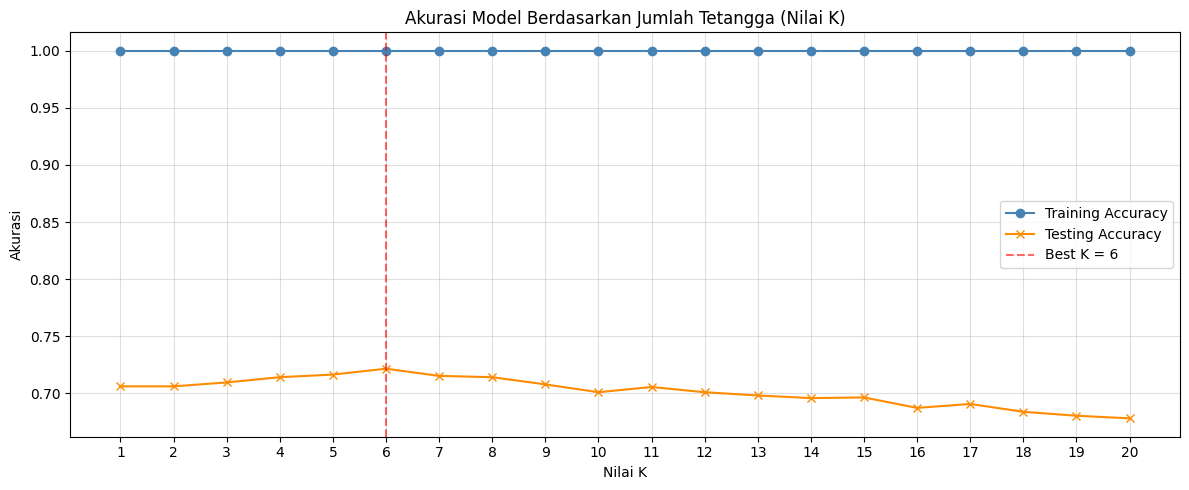

In [105]:
plt.figure(figsize=(12, 5))
plt.plot(k_range, train_scores, label='Training Accuracy',  marker='o', color='steelblue')
plt.plot(k_range, test_scores,  label='Testing Accuracy',   marker='x', color='darkorange')
plt.axvline(x=k_range[np.argmax(test_scores)], color='red',
            linestyle='--', alpha=0.6, label=f'Best K = {k_range[np.argmax(test_scores)]}')
plt.title('Akurasi Model Berdasarkan Jumlah Tetangga (Nilai K)')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [106]:
quick_best_k = k_range[np.argmax(test_scores)]
print(f"K terbaik dari visualisasi: K = {quick_best_k} "
      f"(test accuracy = {max(test_scores)*100:.2f}%)")

K terbaik dari visualisasi: K = 6 (test accuracy = 72.16%)


In [170]:
knn_pipeline = Pipeline([
	('knn', KNeighborsClassifier())
])

param_grid = {
	'knn__n_neighbors': [6, 7, 5, 4, 8],
	'knn__weights': ['uniform', 'distance'],
  'knn__metric': ['euclidean', 'manhattan'],
}

grid_search = GridSearchCV(
	knn_pipeline,
	param_grid,
	cv=5,
	scoring='accuracy',
	n_jobs=-1,
	verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [6, 7, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [171]:
best_model = grid_search.best_estimator_
print(f"Parameter terbaik : {grid_search.best_params_}")
print(f"Akurasi CV terbaik : {grid_search.best_score_*100:.2f}%")
print(f"Best Model : {best_model}")

Parameter terbaik : {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Akurasi CV terbaik : 68.09%
Best Model : Pipeline(steps=[('knn',
                 KNeighborsClassifier(metric='manhattan', weights='distance'))])


## **Evaluation**


In [172]:
y_pred = best_model.predict(X_test)

In [173]:
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Metrik Detail (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred, target_names=KATEGORI))

Akurasi Keseluruhan: 71.64%

Metrik Detail (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

     Plastic       0.70      0.66      0.68       397
       Paper       0.71      0.86      0.78       336
       Metal       0.72      0.48      0.58       204
       Glass       0.76      0.76      0.76       612
  Biological       0.64      0.69      0.67       200

    accuracy                           0.72      1749
   macro avg       0.71      0.69      0.69      1749
weighted avg       0.72      0.72      0.71      1749



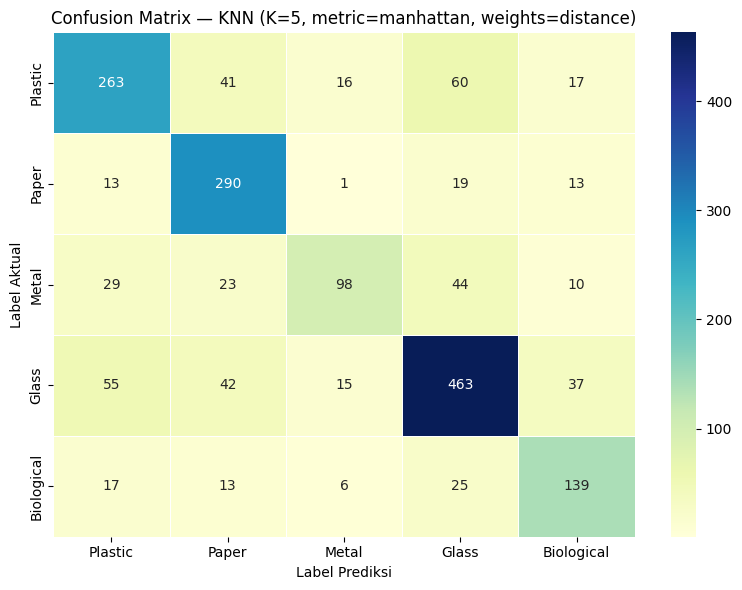

In [174]:
best_k      = grid_search.best_params_['knn__n_neighbors']
best_metric = grid_search.best_params_['knn__metric']
best_weight = grid_search.best_params_['knn__weights']

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=KATEGORI, yticklabels=KATEGORI, linewidths=.5)
plt.title(f'Confusion Matrix — KNN (K={best_k}, metric={best_metric}, weights={best_weight})')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

## **Save Model**


In [175]:
os.makedirs('./model', exist_ok=True)
MODEL_PATH = './model/best_knn_pipeline.pkl'

joblib.dump(best_model, MODEL_PATH)

print(f"Model pipeline berhasil disimpan!")
print(f"Path: {MODEL_PATH}")
print(f"Parameter: K={best_k}, metric={best_metric}, weights={best_weight}")
print(f"Akurasi: {accuracy_score(y_test, y_pred)*100:.2f}%")

Model pipeline berhasil disimpan!
Path: ./model/best_knn_pipeline.pkl
Parameter: K=5, metric=manhattan, weights=distance
Akurasi: 71.64%


## **Inference**


In [195]:
def predict_new_image(image_path, model, kategori=KATEGORI):
    if not os.path.exists(image_path):
        print(f"File tidak ditemukan: {image_path}")
        return None

    img = cv2.imread(image_path)
    if img is None:
        print("Format gambar salah atau korup.")
        return None

    # Resize → ukuran yang sama seperti training
    img_resized = cv2.resize(img, (128, 128))

    # kstraksi fitur mentah (sama persis seperti saat training)
    features = extract_features(img_resized)

    # Prediksi — Pipeline otomatis menerapkan scale + PCA
    prediction = model.predict([features])
    confidence_scores = model.predict_proba([features])[0]
    predicted_class = kategori[prediction[0]]
    confidence = max(confidence_scores) * 100

    # Visualisasi hasil
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_rgb)
    axes[0].axis('off')
    axes[0].set_title(f'Input: {os.path.basename(image_path)}', fontsize=12)

    bar_colors = ['#4CAF50' if i == prediction[0] else '#90CAF9'
                  for i in range(len(kategori))]
    bars = axes[1].barh(kategori, confidence_scores * 100, color=bar_colors)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_xlim(0, 100)
    axes[1].set_title(f'Prediksi: {predicted_class} ({confidence:.1f}%)', fontsize=12)
    axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.4, label='Threshold 50%')
    axes[1].legend(fontsize=9)

    for bar, score in zip(bars, confidence_scores):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                     f'{score*100:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\n🤖 Hasil Analisis   : {predicted_class}")
    print(f"✅ Nilai Kepercayaan : {confidence:.2f}%")
    print(f"\n📊 Distribusi Confidence:")
    for cat, score in zip(kategori, confidence_scores):
        bar_txt = '█' * int(score * 40)
        print(f"   {cat:12s}: {score*100:5.1f}%  {bar_txt}")

    return predicted_class, confidence

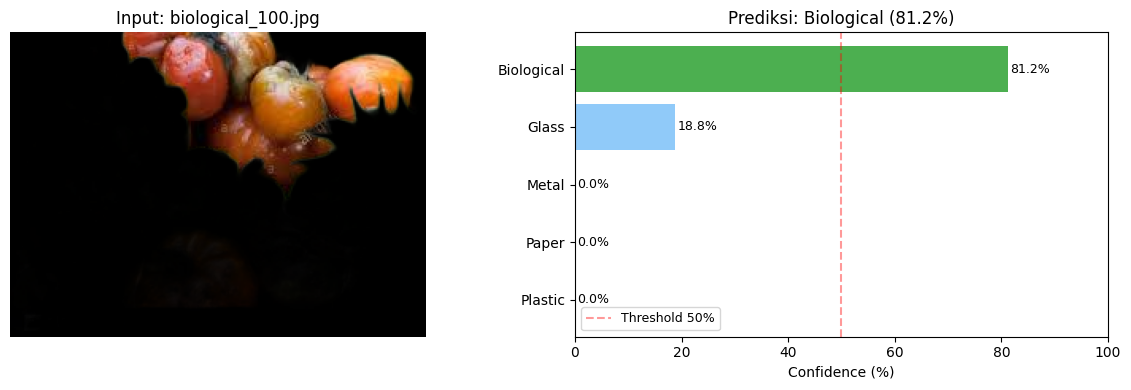


🤖 Hasil Analisis   : Biological
✅ Nilai Kepercayaan : 81.22%

📊 Distribusi Confidence:
   Plastic     :   0.0%  
   Paper       :   0.0%  
   Metal       :   0.0%  
   Glass       :  18.8%  ███████
   Biological  :  81.2%  ████████████████████████████████


('Biological', np.float64(81.21678598772478))

In [203]:
loaded_model = joblib.load(MODEL_PATH)
predict_new_image('./data/biological/biological_100.jpg', loaded_model)